## (a) Data Selection

I used the **SDSS DR19 SkyServer SQL interface** to select galaxies and quasars 
with the following criteria:

- **Redshift range:** \( 0.05 < z < 0.3 \)  
- **Signal-to-noise ratio:** \( S/N > 35 \) (near the Hβ line)

### Emission Line Selection

I required the presence of key emission lines:
- Hβ (4863 Å)
- Hγ (4341 Å)
- [O III] (5007 Å)

These were selected using equivalent width constraints:
- **EW(Hβ) < -10 Å**
- **EW([O III]) < -1 Å**
- **EW(Hγ) < -1 Å**

### FWHM Constraint

To select **broad-line objects**, I imposed a constraint on the Full Width at Half Maximum (FWHM) of the Hβ line.

Assuming a Gaussian profile:

$$
\text{FWHM} \approx 2.355 \times \sigma
$$

Thus, the condition:

$$
\text{FWHM} > 1000 \, \text{km/s}
$$

corresponds to:

$$
\sigma > 424 \, \text{km/s}
$$

This was implemented using the **sigma_balmer** parameter.

### Extracted Parameters

For each object, I extracted:
- Emission line fluxes (Hβ, Hγ, [O III])
- Equivalent widths
- Flux ratios:
  - [O III]/Hβ
  - Hβ/Hγ
  - [O III]/Hγ
- Extinction correction **E(B−V)** from *galSpecInfo*

The final dataset was exported as a **CSV file** for further analysis.

In [14]:
# SQL Query used

### SQL Query for Data Selection 

```sql
SELECT TOP 1000
    s.specobjid,
    s.class,
    s.z,
    s.snmedian_g,

    g.oiii_5007_flux,
    g.h_beta_flux,
    g.h_gamma_flux,

    g.oiii_5007_eqw,
    g.h_beta_eqw,
    g.h_gamma_eqw,

    (g.oiii_5007_flux / NULLIF(g.h_beta_flux,0)) AS OIII_Hbeta,
    (g.h_beta_flux / NULLIF(g.h_gamma_flux,0)) AS Hbeta_Hgamma,
    (g.oiii_5007_flux / NULLIF(g.h_gamma_flux,0)) AS OIII_Hgamma,

    i.e_bv_sfd AS E_BV

FROM SpecObj AS s
JOIN GalSpecLine AS g 
    ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i
    ON s.specobjid = i.specobjid

WHERE 
    (s.class = 'GALAXY' OR s.class = 'QSO')
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.h_beta_eqw < -10
    AND g.oiii_5007_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424
```

## (b) Number of Objects and Constraints
I found a total of **110 objects** satisfying all selection criteria.


### SQL Query Used

```sql
SELECT COUNT(*) 
FROM SpecObj AS s 
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid 
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid

WHERE 
(s.class = 'GALAXY' OR s.class = 'QSO') 
AND s.z BETWEEN 0.05 AND 0.3 
AND s.snmedian_g > 35 
AND g.h_beta_eqw < -10 
AND g.oiii_5007_eqw < -1 
AND g.h_gamma_eqw < -1 
AND g.sigma_balmer > 424
```

To determine which condition narrows the results most severely, I removed one condition at a time while keeping all others fixed and observed the change in the number of objects.

- Removing FWHM → 140  
- Removing Hβ → 153  
- Removing Hγ → 110 (no change)  
- Removing [O III] → 110 (no change)  
- Removing redshift → 213  
- Removing signal-to-noise → 2662  

From these results, it is clear that removing the signal-to-noise condition (snmedian_g > 35) leads to the largest increase in the number of objects (from 110 to 2662).

Therefore, the signal-to-noise condition is the most restrictive, as it narrows the results most severely among all the applied conditions.

## (c) AGN Subclass Selection
I modified the selection criteria by adding a constraint on the subclass:

`s.subclass LIKE '%AGN%'`

This allows me to select only objects classified as Active Galactic Nuclei (AGN) under the same conditions as in part (a).

The query returned a total of **5 objects**, indicating that only a small fraction of the selected galaxies and quasars belong to the AGN subclass.

All identified AGN objects are classified as **"AGN BROADLINE"** and belong to the **QSO class**.

This confirms that AGN are present in the dataset, but they represent a very small subset under the given selection criteria.

```sql
To inspect the properties of AGN objects in detail, I first retrieved a sample of the data using the following query:
SELECT TOP 1000
    s.specobjid,
    s.class,
    s.subclass,
    s.z,
    s.snmedian_g,

    g.oiii_5007_flux,
    g.h_beta_flux,
    g.h_gamma_flux,

    (g.oiii_5007_flux / NULLIF(g.h_beta_flux,0)) AS OIII_Hbeta,
    (g.h_beta_flux / NULLIF(g.h_gamma_flux,0)) AS Hbeta_Hgamma,
    (g.oiii_5007_flux / NULLIF(g.h_gamma_flux,0)) AS OIII_Hgamma

FROM SpecObj AS s
JOIN GalSpecLine AS g 
    ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i
    ON s.specobjid = i.specobjid

WHERE 
    (s.class = 'GALAXY' OR s.class = 'QSO')
    AND s.subclass LIKE '%AGN%'
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.h_beta_eqw < -10
    AND g.oiii_5007_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424
```

```sql
To determine the total number of AGN objects satisfying all the selection criteria, I executed the following query:
SELECT COUNT(*)
FROM SpecObj AS s
JOIN GalSpecLine AS g 
    ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i
    ON s.specobjid = i.specobjid

WHERE 
    (s.class = 'GALAXY' OR s.class = 'QSO')
    AND s.subclass LIKE '%AGN%'
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.h_beta_eqw < -10
    AND g.oiii_5007_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424
```

## (d) Extended Redshift Selection and CrossID

I modified the redshift constraint to extend the range from 0.05 < z < 0.3 to 0.05 < z < 0.6.



```sql
SELECT 
    s.plate,
    s.mjd,
    s.fiberid
FROM SpecObj AS s
JOIN GalSpecLine AS g 
    ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i
    ON s.specobjid = i.specobjid

WHERE 
    (s.class = 'GALAXY' OR s.class = 'QSO')
    AND s.z BETWEEN 0.05 AND 0.6
    AND s.snmedian_g > 35
    AND g.h_beta_eqw < -10
    AND g.oiii_5007_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424
```

Using this modified query, I obtained a list of objects identified by their plate, MJD, and fiberID.

I then used the SDSS CrossID tool to match these objects with the provided list (287-plate-MJD-fiber.txt). The upload type was set to *plate–MJD–fiberID*, and no header row was included in the file. The number of preceding non-data columns was set to 0.

I then performed a cross-match by joining the uploaded table with the `SpecObjAll` table using the following SQL query:

```sql
SELECT 
    s.specobjid,
    s.plate,
    s.mjd,
    s.fiberid,
    s.z
FROM #upload u
JOIN SpecObjAll s 
    ON s.plate = u.up_plate
    AND s.mjd = u.up_mjd
    AND s.fiberid = u.up_fiber

## (e) Checking and Downloading Spectra

To examine the spectral properties of the selected objects, I used the SDSS SkyServer Explore tool. Each object was accessed using its plate–MJD–fiber identifier.

I then navigated to the “Optical Spectra” section, where I could directly view the spectra of the objects. These plots show how flux varies with wavelength, and the main emission lines such as Hβ and [O III] were clearly visible.

After visually inspecting the spectra, I downloaded several of them in FITS format using the available download options. These files store the full spectral data, including wavelength and flux values.

By looking at the spectra, I was able to confirm that the required emission features are present, which indicates that the selected objects satisfy the conditions defined earlier.

The downloaded FITS files were later used for further analysis and visualization using Python tools such as Astropy and Matplotlib.

### (f) Reading and Plotting Spectra using Python

To further analyze the downloaded spectra, I used Python to read the FITS files and visualize the spectral data. The analysis was performed using the Astropy library for handling FITS files and Matplotlib for plotting.

Each FITS file contains spectral information such as flux and wavelength. The wavelength was obtained by converting the logarithmic wavelength values (loglam) into linear scale. The flux was then plotted as a function of wavelength to produce the spectrum.

The resulting plots show characteristic emission features, allowing for visual inspection of spectral lines such as Hβ and [O III].

In [15]:
pip install astropy matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


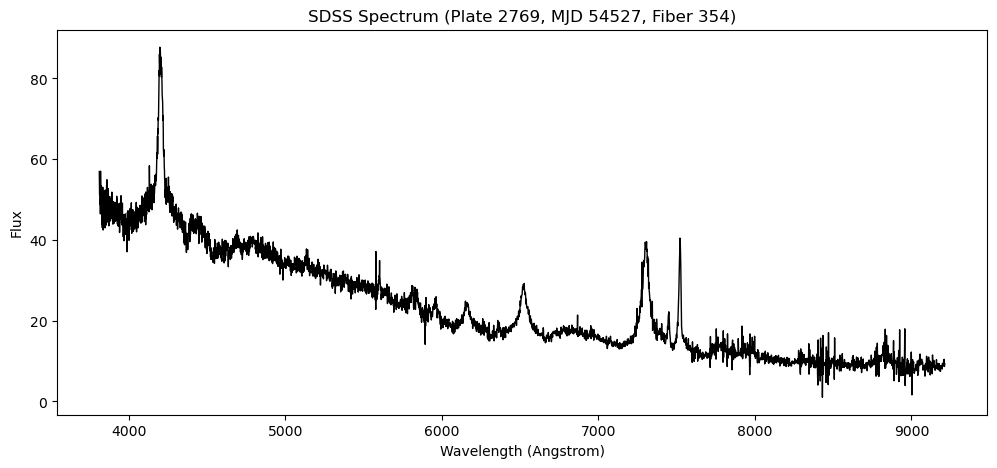

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# file path
hdul = fits.open(r"/home/israt/Downloads/spec-1.fits")

# data read
data = hdul[1].data

flux = data['flux']
loglam = data['loglam']

# wavelength calculate
wavelength = 10**loglam

# plot
plt.figure(figsize=(12,5))
plt.plot(wavelength, flux, color='black', linewidth=1)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("SDSS Spectrum (Plate 2769, MJD 54527, Fiber 354)")

plt.savefig(r"/home/israt/Downloads/spectrum_1.png", dpi=300, bbox_inches='tight')

plt.show()

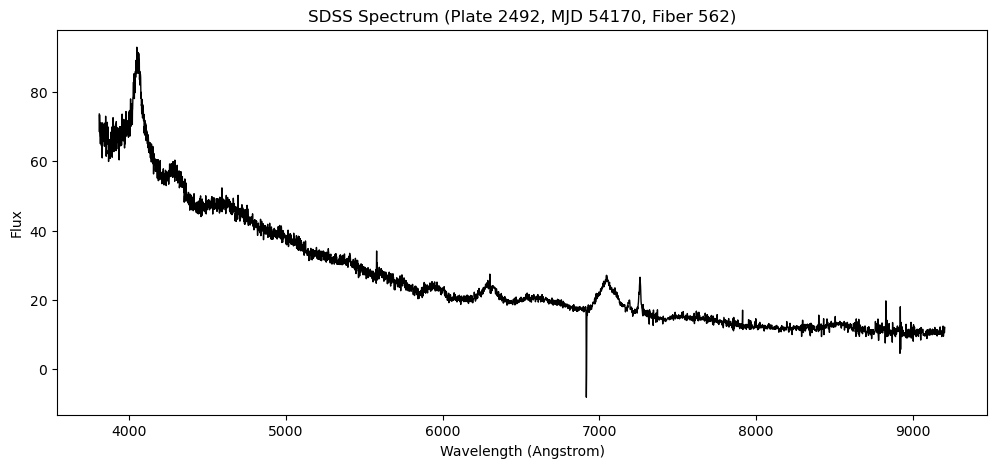

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# file path
hdul = fits.open(r"/home/israt/Downloads/spec-2.fits")

# data read
data = hdul[1].data

flux = data['flux']
loglam = data['loglam']

# wavelength calculate
wavelength = 10**loglam

# plot
plt.figure(figsize=(12,5))
plt.plot(wavelength, flux, color='black', linewidth=1)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("SDSS Spectrum (Plate 2492, MJD 54170, Fiber 562)")

plt.savefig(r"/home/israt/Downloads/spectrum_2.png", dpi=300, bbox_inches='tight')

plt.show()

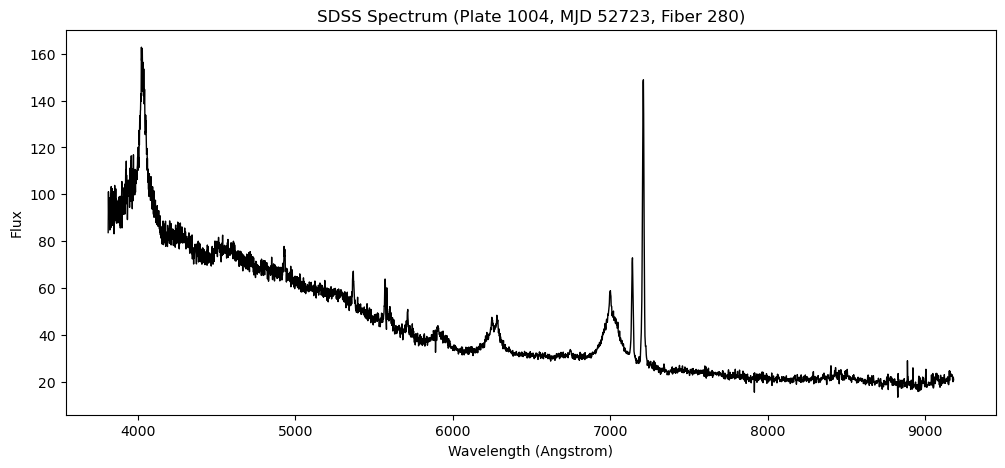

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# file path
hdul = fits.open(r"/home/israt/Downloads/spec-3.fits")

# data read
data = hdul[1].data

flux = data['flux']
loglam = data['loglam']

# wavelength calculate
wavelength = 10**loglam

# plot
plt.figure(figsize=(12,5))
plt.plot(wavelength, flux, color='black', linewidth=1)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("SDSS Spectrum (Plate 1004, MJD 52723, Fiber 280)")

plt.savefig(r"/home/israt/Downloads/spectrum_3.png", dpi=300, bbox_inches='tight')

plt.show()